<a href="https://colab.research.google.com/github/m2nwo079/global-challenger-2026/blob/main/06_module_d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os
for p in [f'{BASE}/output', f'{BASE}/figures']:
    os.makedirs(p, exist_ok=True)

BASE = '/content/drive/MyDrive/globalchallenger'
plt.rcParams['savefig.dpi']  = 300
plt.rcParams['savefig.bbox'] = 'tight'

def sample_size(p, mde_rel, alpha=0.05, power=0.80):
    """Per-arm sample size for a two-proportion test."""
    p2 = p * (1 + mde_rel)
    pbar = (p + p2) / 2
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    num = (z_a * np.sqrt(2 * pbar * (1 - pbar))
           + z_b * np.sqrt(p * (1 - p) + p2 * (1 - p2))) ** 2
    return num / (p2 - p) ** 2

rows = []
for p, name in [(0.3612, 'CTR (measured, module A)'),
                (0.0030, 'Conversion rate (module C)'),
                (0.0470, 'Visit rate (module C)')]:
    for mde in [0.01, 0.02, 0.05, 0.10, 0.20]:
        n = sample_size(p, mde)
        rows.append({'baseline': name, 'baseline_rate': p,
                     'mde_relative': mde, 'n_per_arm': int(np.ceil(n)),
                     'n_total': int(np.ceil(2 * n))})

ss = pd.DataFrame(rows)
print(ss.to_string(index=False))

                  baseline  baseline_rate  mde_relative  n_per_arm   n_total
  CTR (measured, module A)         0.3612          0.01     278221    556442
  CTR (measured, module A)         0.3612          0.02      69703    139405
  CTR (measured, module A)         0.3612          0.05      11221     22441
  CTR (measured, module A)         0.3612          0.10       2832      5663
  CTR (measured, module A)         0.3612          0.20        720      1439
Conversion rate (module C)         0.0030          0.01   52428942 104857884
Conversion rate (module C)         0.0030          0.02   13172247  26344493
Conversion rate (module C)         0.0030          0.05    2138763   4277525
Conversion rate (module C)         0.0030          0.10     547690   1095380
Conversion rate (module C)         0.0030          0.20     143421    286841
     Visit rate (module C)         0.0470          0.01    3198097   6396193
     Visit rate (module C)         0.0470          0.02     803303   1606606

In [17]:
from google.colab import drive
drive.mount('/content/drive')

import os
for p in [f'{BASE}/output', f'{BASE}/figures']:
    os.makedirs(p, exist_ok=True)

print('output :', os.path.isdir(f'{BASE}/output'))
print('figures:', os.path.isdir(f'{BASE}/figures'))
print('existing:', sorted(os.listdir(f'{BASE}/output')))

def days_needed(p, mde_rel, daily_users, treat_share=0.5):
    n = sample_size(p, mde_rel)
    per_day = daily_users * min(treat_share, 1 - treat_share)
    return n / per_day

rows = []
for share in [0.03, 0.05, 0.10, 0.50]:
    for mde in [0.02, 0.05, 0.10, 0.20]:
        rows.append({
            'rollout': f'{share:.0%}',
            'mde':     f'{mde:.0%}',
            'days_ctr':  round(days_needed(0.3612, mde, 1_000_000 * share), 1),
            'days_conv': round(days_needed(0.0030, mde, 1_000_000 * share), 1),
        })
dd = pd.DataFrame(rows)
print('assuming 1,000,000 daily eligible users, 50/50 split within the rollout')
print(dd.to_string(index=False))

Mounted at /content/drive
output : True
figures: True
existing: ['module_a.json', 'module_b.json', 'module_c.json', 'synthesis.json']
assuming 1,000,000 daily eligible users, 50/50 split within the rollout
rollout mde  days_ctr  days_conv
     3%  2%       4.6      878.1
     3%  5%       0.7      142.6
     3% 10%       0.2       36.5
     3% 20%       0.0        9.6
     5%  2%       2.8      526.9
     5%  5%       0.4       85.6
     5% 10%       0.1       21.9
     5% 20%       0.0        5.7
    10%  2%       1.4      263.4
    10%  5%       0.2       42.8
    10% 10%       0.1       11.0
    10% 20%       0.0        2.9
    50%  2%       0.3       52.7
    50%  5%       0.0        8.6
    50% 10%       0.0        2.2
    50% 20%       0.0        0.6


In [14]:
rng = np.random.default_rng(0)

def peeking_fpr(p, n_per_arm, n_looks, n_sims=4000, alpha=0.05):
    """False positive rate under no true effect, testing at each look."""
    batch = n_per_arm // n_looks
    z_crit = stats.norm.ppf(1 - alpha / 2)
    rejected_any = 0
    rejected_final = 0
    for _ in range(n_sims):
        a = rng.random(n_per_arm) < p
        b = rng.random(n_per_arm) < p
        hit = False
        for L in range(1, n_looks + 1):
            m = L * batch
            pa, pb = a[:m].mean(), b[:m].mean()
            pbar = (pa + pb) / 2
            se = np.sqrt(2 * pbar * (1 - pbar) / m)
            if se > 0 and abs(pa - pb) / se > z_crit:
                hit = True
                if L == n_looks:
                    rejected_final += 1
                break
            if L == n_looks:
                pass
        rejected_any += hit
    return rejected_any / n_sims

rows = []
for looks in [1, 2, 5, 10, 20]:
    rows.append({
        'looks': looks,
        'fpr_ctr':  peeking_fpr(0.3612, 20_000, looks),
        'fpr_conv': peeking_fpr(0.0030, 400_000, looks, n_sims=1500),
    })
pk = pd.DataFrame(rows)
print('nominal alpha = 0.05, no true effect')
print(pk.to_string(index=False, float_format='%.4f'))

nominal alpha = 0.05, no true effect
 looks  fpr_ctr  fpr_conv
     1   0.0432    0.0493
     2   0.0872    0.0987
     5   0.1422    0.1327
    10   0.1943    0.1760
    20   0.2385    0.2507


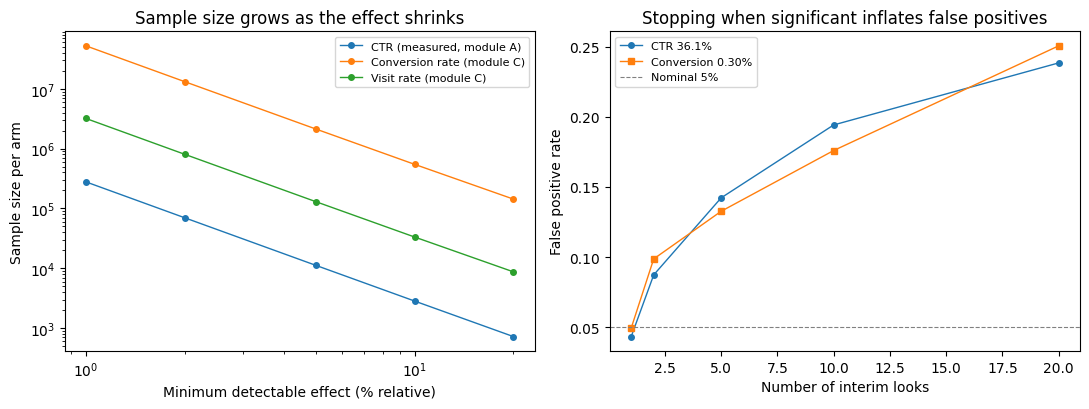

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

for name, g in ss.groupby('baseline'):
    ax[0].plot(g.mde_relative * 100, g.n_per_arm, marker='o', ms=4, lw=1,
               label=name)
ax[0].set(xscale='log', yscale='log',
          xlabel='Minimum detectable effect (% relative)',
          ylabel='Sample size per arm',
          title='Sample size grows as the effect shrinks')
ax[0].legend(fontsize=8)

ax[1].plot(pk.looks, pk.fpr_ctr, marker='o', ms=4, lw=1, label='CTR 36.1%')
ax[1].plot(pk.looks, pk.fpr_conv, marker='s', ms=4, lw=1,
           label='Conversion 0.30%')
ax[1].axhline(0.05, color='gray', lw=0.8, ls='--', label='Nominal 5%')
ax[1].set(xlabel='Number of interim looks', ylabel='False positive rate',
          title='Stopping when significant inflates false positives')
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_d_power.png')
plt.show()

In [19]:
import json, os
out = {
    'assumptions': {
        'alpha': 0.05, 'power': 0.80,
        'baseline_ctr': 0.3612, 'baseline_conversion': 0.0030,
        'baseline_visit': 0.0470,
        'daily_eligible_users_assumed': 1_000_000,
        'note': 'Baseline rates come from modules A and C. Daily user '
                'volume is an illustrative assumption, not an estimate of '
                'any specific platform.',
    },
    'sample_size': ss.to_dict('records'),
    'days_needed': dd.to_dict('records'),
    'peeking_false_positive_rate': pk.to_dict('records'),
}
with open(f'{BASE}/output/module_d.json', 'w') as f:
    json.dump(out, f, indent=2)
print('saved:', os.path.getsize(f'{BASE}/output/module_d.json'), 'bytes')

saved: 5051 bytes
